# Cración base de datos artificial

In [2]:
import pandas as pd
import random
from datetime import datetime, timedelta

# ==========================================
# CONFIGURACIÓN
# ==========================================

NUM_SEMANAS = 520
FECHA_INICIO = datetime(2025, 1, 1)

temporadas = ["Normal", "Escolar", "Navidad", "Vacaciones"]

# ==========================================
# GENERACIÓN DE DATOS
# ==========================================

datos = []

# Stock inicial base
stock_S = 50
stock_M = 70
stock_L = 40

for semana in range(1, NUM_SEMANAS + 1):

    fecha = FECHA_INICIO + timedelta(weeks=semana - 1)

    # Variables aleatorias
    promocion = random.choice([True, False])
    quincena = random.choice([True, False])
    temporada = random.choice(temporadas)

    temperatura = round(random.uniform(15, 30), 1)

    # ==========================================
    # GENERAR DEMANDA BASE
    # ==========================================

    ventas_S = random.randint(3, 10)
    ventas_M = random.randint(8, 20)
    ventas_L = random.randint(2, 8)

    # ==========================================
    # AJUSTES POR TEMPORADA
    # ==========================================

    if temporada == "Escolar":
        ventas_S += random.randint(2, 5)

    elif temporada == "Navidad":
        ventas_S += random.randint(3, 6)
        ventas_M += random.randint(5, 10)
        ventas_L += random.randint(3, 6)

    elif temporada == "Vacaciones":
        ventas_M += random.randint(2, 5)

    # ==========================================
    # AJUSTES POR PROMOCIÓN
    # ==========================================

    if promocion:
        ventas_M += random.randint(3, 8)
        ventas_L += random.randint(2, 5)

    # ==========================================
    # STOCK INICIAL
    # ==========================================

    stock_inicial_S = stock_S
    stock_inicial_M = stock_M
    stock_inicial_L = stock_L

    # ==========================================
    # CALCULAR STOCK FINAL
    # ==========================================

    stock_final_S = max(stock_inicial_S - ventas_S, 0)
    stock_final_M = max(stock_inicial_M - ventas_M, 0)
    stock_final_L = max(stock_inicial_L - ventas_L, 0)

    # ==========================================
    # DETECTAR FALTANTES
    # ==========================================

    faltante_S = stock_final_S <= 5
    faltante_M = stock_final_M <= 5
    faltante_L = stock_final_L <= 5

    # ==========================================
    # PEDIDOS AUTOMÁTICOS
    # ==========================================

    pedido_S = 0
    pedido_M = 0
    pedido_L = 0

    if stock_final_S < 15:
        pedido_S = random.randint(20, 40)

    if stock_final_M < 20:
        pedido_M = random.randint(30, 50)

    if stock_final_L < 15:
        pedido_L = random.randint(20, 35)

    # ==========================================
    # ACTUALIZAR STOCK PARA SIGUIENTE SEMANA
    # ==========================================

    stock_S = stock_final_S + pedido_S
    stock_M = stock_final_M + pedido_M
    stock_L = stock_final_L + pedido_L

    # ==========================================
    # GUARDAR FILA
    # ==========================================

    datos.append({
        "id_semana": semana,
        "fecha_inicio": fecha.strftime("%Y-%m-%d"),

        "ventas_S": ventas_S,
        "ventas_M": ventas_M,
        "ventas_L": ventas_L,

        "stock_inicial_S": stock_inicial_S,
        "stock_inicial_M": stock_inicial_M,
        "stock_inicial_L": stock_inicial_L,

        "stock_final_S": stock_final_S,
        "stock_final_M": stock_final_M,
        "stock_final_L": stock_final_L,

        "pedido_realizado_S": pedido_S,
        "pedido_realizado_M": pedido_M,
        "pedido_realizado_L": pedido_L,

        "promocion": promocion,
        "temporada": temporada,
        "temperatura_promedio": temperatura,
        "quincena": quincena,

        "faltante_S": faltante_S,
        "faltante_M": faltante_M,
        "faltante_L": faltante_L
    })

# ==========================================
# CREAR DATAFRAME
# ==========================================

df = pd.DataFrame(datos)

# ==========================================
# EXPORTAR CSV
# ==========================================

nombre_archivo = "inventario_semanal.csv"

df.to_csv(nombre_archivo, index=False)

print(f"CSV generado correctamente: {nombre_archivo}")

# Mostrar primeras filas
print("\nPrimeras filas del dataset:\n")
print(df.head())

CSV generado correctamente: inventario_semanal.csv

Primeras filas del dataset:

   id_semana fecha_inicio  ventas_S  ventas_M  ventas_L  stock_inicial_S  \
0          1   2025-01-01        11        13         2               50   
1          2   2025-01-08         4        18         8               39   
2          3   2025-01-15        10        28         9               35   
3          4   2025-01-22         5        18         7               25   
4          5   2025-01-29         5        16         7               20   

   stock_inicial_M  stock_inicial_L  stock_final_S  stock_final_M  ...  \
0               70               40             39             57  ...   
1               57               38             35             39  ...   
2               39               30             25             11  ...   
3               51               21             20             33  ...   
4               33               49             15             17  ...   

   pedido_realiza

# Grafo de relaciones

INFORMACIÓN DEL GRAFO
Nodos: 520
Conexiones: 3815


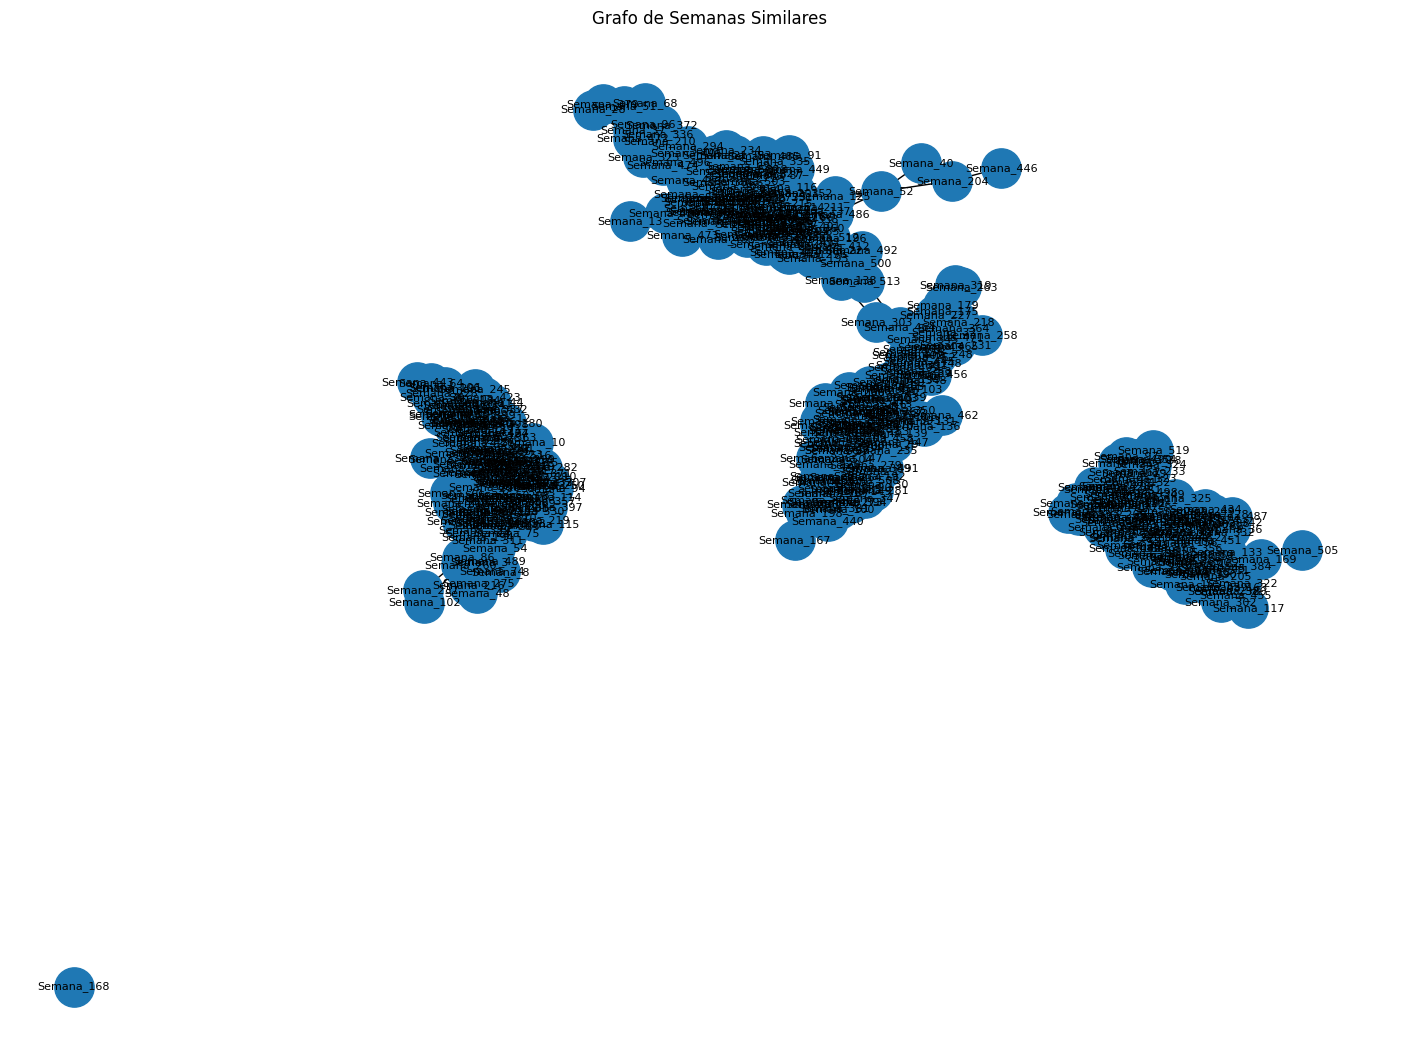


EJEMPLO DE CONEXIONES
('Semana_1', 'Semana_90', {'peso': 4})
('Semana_1', 'Semana_130', {'peso': 3})
('Semana_1', 'Semana_149', {'peso': 4})
('Semana_1', 'Semana_154', {'peso': 5})
('Semana_1', 'Semana_192', {'peso': 4})
('Semana_1', 'Semana_235', {'peso': 5})
('Semana_1', 'Semana_264', {'peso': 5})
('Semana_1', 'Semana_279', {'peso': 4})
('Semana_1', 'Semana_281', {'peso': 2})
('Semana_1', 'Semana_347', {'peso': 5})


In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# CARGAR CSV
# ==========================================

df = pd.read_csv("inventario_semanal.csv")

# ==========================================
# CREAR GRAFO
# ==========================================

"""
Cada nodo representa una semana.

Las conexiones se crean según similitud
de comportamiento de ventas.

Ejemplo:
- ventas parecidas
- misma temporada
- misma promoción

Esto permitirá aplicar BFS y DFS luego.
"""

G = nx.Graph()

# ==========================================
# AGREGAR NODOS
# ==========================================

for _, fila in df.iterrows():

    nodo = f"Semana_{fila['id_semana']}"

    G.add_node(
        nodo,

        ventas_S=fila['ventas_S'],
        ventas_M=fila['ventas_M'],
        ventas_L=fila['ventas_L'],

        temporada=fila['temporada'],
        promocion=fila['promocion']
    )

# ==========================================
# CREAR CONEXIONES ENTRE SEMANAS
# ==========================================

"""
Conectamos semanas si:

1. La diferencia de ventas es pequeña
2. La temporada es igual

Esto genera un grafo de semanas similares.
"""

UMBRAL_DIFERENCIA = 5

for i in range(len(df)):

    for j in range(i + 1, len(df)):

        fila1 = df.iloc[i]
        fila2 = df.iloc[j]

        nodo1 = f"Semana_{fila1['id_semana']}"
        nodo2 = f"Semana_{fila2['id_semana']}"

        # Diferencia total entre ventas
        diferencia = (
            abs(fila1['ventas_S'] - fila2['ventas_S']) +
            abs(fila1['ventas_M'] - fila2['ventas_M']) +
            abs(fila1['ventas_L'] - fila2['ventas_L'])
        )

        misma_temporada = (
            fila1['temporada'] == fila2['temporada']
        )

        # Crear conexión
        if diferencia <= UMBRAL_DIFERENCIA and misma_temporada:

            G.add_edge(
                nodo1,
                nodo2,
                peso=diferencia
            )

# ==========================================
# INFORMACIÓN DEL GRAFO
# ==========================================

print("===================================")
print("INFORMACIÓN DEL GRAFO")
print("===================================")

print(f"Nodos: {G.number_of_nodes()}")
print(f"Conexiones: {G.number_of_edges()}")

# ==========================================
# VISUALIZACIÓN
# ==========================================

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=800,
    font_size=8
)

plt.title("Grafo de Semanas Similares")
plt.show()

# ==========================================
# MOSTRAR ALGUNAS CONEXIONES
# ==========================================

print("\n===================================")
print("EJEMPLO DE CONEXIONES")
print("===================================")

for edge in list(G.edges(data=True))[:10]:
    print(edge)

In [4]:
import pandas as pd
import networkx as nx
from collections import deque

# ==========================================
# CARGAR CSV
# ==========================================

df = pd.read_csv("inventario_semanal.csv")

# ==========================================
# CREAR GRAFO
# ==========================================

G = nx.Graph()

# ------------------------------------------
# AGREGAR NODOS
# ------------------------------------------

for _, fila in df.iterrows():

    nodo = f"Semana_{fila['id_semana']}"

    G.add_node(
        nodo,

        ventas_S=fila['ventas_S'],
        ventas_M=fila['ventas_M'],
        ventas_L=fila['ventas_L'],

        temporada=fila['temporada'],
        promocion=fila['promocion'],

        faltante_M=fila['faltante_M']
    )

# ------------------------------------------
# AGREGAR CONEXIONES
# ------------------------------------------

UMBRAL_DIFERENCIA = 5

for i in range(len(df)):

    for j in range(i + 1, len(df)):

        fila1 = df.iloc[i]
        fila2 = df.iloc[j]

        nodo1 = f"Semana_{fila1['id_semana']}"
        nodo2 = f"Semana_{fila2['id_semana']}"

        diferencia = (
            abs(fila1['ventas_S'] - fila2['ventas_S']) +
            abs(fila1['ventas_M'] - fila2['ventas_M']) +
            abs(fila1['ventas_L'] - fila2['ventas_L'])
        )

        misma_temporada = (
            fila1['temporada'] == fila2['temporada']
        )

        if diferencia <= UMBRAL_DIFERENCIA and misma_temporada:

            G.add_edge(
                nodo1,
                nodo2,
                peso=diferencia
            )

# ==========================================
# BFS
# ==========================================

def bfs(grafo, inicio):

    visitados = set()

    cola = deque([inicio])

    resultado = []

    while cola:

        nodo = cola.popleft()

        if nodo not in visitados:

            visitados.add(nodo)

            resultado.append(nodo)

            for vecino in grafo.neighbors(nodo):

                if vecino not in visitados:
                    cola.append(vecino)

    return resultado

# ==========================================
# DFS
# ==========================================

def dfs(grafo, nodo, visitados=None, resultado=None):

    if visitados is None:
        visitados = set()

    if resultado is None:
        resultado = []

    visitados.add(nodo)

    resultado.append(nodo)

    for vecino in grafo.neighbors(nodo):

        if vecino not in visitados:

            dfs(grafo, vecino, visitados, resultado)

    return resultado

# ==========================================
# EJECUCIÓN BFS
# ==========================================

semana_inicio = "Semana_20"

print("===================================")
print("BFS - SEMANAS SIMILARES")
print("===================================")

resultado_bfs = bfs(G, semana_inicio)

for nodo in resultado_bfs:

    datos = G.nodes[nodo]

    print(f"""
{nodo}
Ventas S: {datos['ventas_S']}
Ventas M: {datos['ventas_M']}
Ventas L: {datos['ventas_L']}
Temporada: {datos['temporada']}
Promoción: {datos['promocion']}
Faltante M: {datos['faltante_M']}
""")

# ==========================================
# ANALISIS BFS
# ==========================================

faltantes = 0

for nodo in resultado_bfs:

    if G.nodes[nodo]['faltante_M']:
        faltantes += 1

print("===================================")
print("ANÁLISIS BFS")
print("===================================")

print(f"Semanas similares encontradas: {len(resultado_bfs)}")
print(f"Semanas con faltante de talla M: {faltantes}")

if faltantes > 0:

    print("""
RECOMENDACIÓN:
Aumentar el pedido de talla M
porque semanas similares terminaron
con problemas de stock.
""")

else:

    print("""
RECOMENDACIÓN:
El stock actual parece suficiente
según semanas históricas similares.
""")

# ==========================================
# EJECUCIÓN DFS
# ==========================================

print("\n===================================")
print("DFS - SECUENCIAS HISTÓRICAS")
print("===================================")

resultado_dfs = dfs(G, semana_inicio)

for nodo in resultado_dfs:

    datos = G.nodes[nodo]

    print(f"""
{nodo}
Ventas S: {datos['ventas_S']}
Ventas M: {datos['ventas_M']}
Ventas L: {datos['ventas_L']}
Temporada: {datos['temporada']}
Promoción: {datos['promocion']}
""")

# ==========================================
# ANÁLISIS DFS
# ==========================================

print("===================================")
print("ANÁLISIS DFS")
print("===================================")

print(f"Total de semanas recorridas: {len(resultado_dfs)}")

print("""
DFS permitió explorar secuencias completas
de comportamiento histórico.

Esto ayuda a detectar:
- patrones largos de demanda,
- secuencias críticas,
- posibles ciclos de faltantes,
- comportamientos repetitivos.
""")

BFS - SEMANAS SIMILARES

Semana_20
Ventas S: 7
Ventas M: 18
Ventas L: 8
Temporada: Normal
Promoción: True
Faltante M: False


Semana_2
Ventas S: 4
Ventas M: 18
Ventas L: 8
Temporada: Normal
Promoción: False
Faltante M: False


Semana_4
Ventas S: 5
Ventas M: 18
Ventas L: 7
Temporada: Normal
Promoción: False
Faltante M: False


Semana_5
Ventas S: 5
Ventas M: 16
Ventas L: 7
Temporada: Normal
Promoción: False
Faltante M: False


Semana_18
Ventas S: 7
Ventas M: 22
Ventas L: 8
Temporada: Normal
Promoción: True
Faltante M: False


Semana_30
Ventas S: 8
Ventas M: 20
Ventas L: 6
Temporada: Normal
Promoción: False
Faltante M: False


Semana_55
Ventas S: 4
Ventas M: 17
Ventas L: 9
Temporada: Normal
Promoción: True
Faltante M: False


Semana_81
Ventas S: 8
Ventas M: 19
Ventas L: 6
Temporada: Normal
Promoción: True
Faltante M: False


Semana_113
Ventas S: 5
Ventas M: 21
Ventas L: 8
Temporada: Normal
Promoción: True
Faltante M: True


Semana_121
Ventas S: 5
Ventas M: 18
Ventas L: 8
Temporada: Normal

In [5]:
import pandas as pd
import networkx as nx
from collections import deque
import math

# ==========================================
# CARGAR CSV
# ==========================================

df = pd.read_csv("inventario_semanal.csv")

# ==========================================
# CREAR GRAFO
# ==========================================

G = nx.Graph()

# ------------------------------------------
# AGREGAR NODOS
# ------------------------------------------

for _, fila in df.iterrows():

    nodo = f"Semana_{fila['id_semana']}"

    G.add_node(
        nodo,

        ventas_S=fila['ventas_S'],
        ventas_M=fila['ventas_M'],
        ventas_L=fila['ventas_L'],

        stock_final_S=fila['stock_final_S'],
        stock_final_M=fila['stock_final_M'],
        stock_final_L=fila['stock_final_L'],

        temporada=fila['temporada'],
        promocion=fila['promocion'],

        faltante_S=fila['faltante_S'],
        faltante_M=fila['faltante_M'],
        faltante_L=fila['faltante_L']
    )

# ------------------------------------------
# CREAR CONEXIONES
# ------------------------------------------

UMBRAL_DIFERENCIA = 5

for i in range(len(df)):

    for j in range(i + 1, len(df)):

        fila1 = df.iloc[i]
        fila2 = df.iloc[j]

        nodo1 = f"Semana_{fila1['id_semana']}"
        nodo2 = f"Semana_{fila2['id_semana']}"

        diferencia = (
            abs(fila1['ventas_S'] - fila2['ventas_S']) +
            abs(fila1['ventas_M'] - fila2['ventas_M']) +
            abs(fila1['ventas_L'] - fila2['ventas_L'])
        )

        misma_temporada = (
            fila1['temporada'] == fila2['temporada']
        )

        if diferencia <= UMBRAL_DIFERENCIA and misma_temporada:

            G.add_edge(
                nodo1,
                nodo2,
                peso=diferencia
            )

# ==========================================
# BFS
# ==========================================

def bfs(grafo, inicio):

    visitados = set()

    cola = deque([inicio])

    resultado = []

    while cola:

        nodo = cola.popleft()

        if nodo not in visitados:

            visitados.add(nodo)

            resultado.append(nodo)

            for vecino in grafo.neighbors(nodo):

                if vecino not in visitados:
                    cola.append(vecino)

    return resultado

# ==========================================
# SEMANA ACTUAL
# ==========================================

semana_actual = "Semana_20"

# ==========================================
# OBTENER SEMANAS SIMILARES
# ==========================================

semanas_similares = bfs(G, semana_actual)

print("===================================")
print("SEMANA ANALIZADA")
print("===================================")

print(semana_actual)

print("\n===================================")
print("SEMANAS SIMILARES ENCONTRADAS")
print("===================================")

for semana in semanas_similares:
    print(semana)

# ==========================================
# CALCULAR PROMEDIOS HISTÓRICOS
# ==========================================

ventas_S = []
ventas_M = []
ventas_L = []

faltantes_S = 0
faltantes_M = 0
faltantes_L = 0

for semana in semanas_similares:

    datos = G.nodes[semana]

    ventas_S.append(datos['ventas_S'])
    ventas_M.append(datos['ventas_M'])
    ventas_L.append(datos['ventas_L'])

    if datos['faltante_S']:
        faltantes_S += 1

    if datos['faltante_M']:
        faltantes_M += 1

    if datos['faltante_L']:
        faltantes_L += 1

# ==========================================
# PROMEDIOS
# ==========================================

promedio_S = sum(ventas_S) / len(ventas_S)
promedio_M = sum(ventas_M) / len(ventas_M)
promedio_L = sum(ventas_L) / len(ventas_L)

# ==========================================
# MARGEN DE SEGURIDAD
# ==========================================

"""
Si hubo muchos faltantes históricos,
aumentamos el margen.
"""

def calcular_margen(faltantes, total):

    ratio = faltantes / total

    if ratio > 0.5:
        return 0.50

    elif ratio > 0.3:
        return 0.35

    elif ratio > 0.1:
        return 0.20

    else:
        return 0.10

margen_S = calcular_margen(faltantes_S, len(semanas_similares))
margen_M = calcular_margen(faltantes_M, len(semanas_similares))
margen_L = calcular_margen(faltantes_L, len(semanas_similares))

# ==========================================
# PEDIDO RECOMENDADO
# ==========================================

pedido_S = math.ceil(promedio_S * (1 + margen_S))
pedido_M = math.ceil(promedio_M * (1 + margen_M))
pedido_L = math.ceil(promedio_L * (1 + margen_L))

# ==========================================
# NIVEL DE RIESGO
# ==========================================

def nivel_riesgo(faltantes, total):

    ratio = faltantes / total

    if ratio > 0.5:
        return "ALTO"

    elif ratio > 0.25:
        return "MEDIO"

    else:
        return "BAJO"

riesgo_S = nivel_riesgo(faltantes_S, len(semanas_similares))
riesgo_M = nivel_riesgo(faltantes_M, len(semanas_similares))
riesgo_L = nivel_riesgo(faltantes_L, len(semanas_similares))

# ==========================================
# RESULTADOS
# ==========================================

print("\n===================================")
print("ANÁLISIS HISTÓRICO")
print("===================================")

print(f"Promedio ventas S: {promedio_S:.2f}")
print(f"Promedio ventas M: {promedio_M:.2f}")
print(f"Promedio ventas L: {promedio_L:.2f}")

print("\n===================================")
print("FALTANTES HISTÓRICOS")
print("===================================")

print(f"Faltantes S: {faltantes_S}")
print(f"Faltantes M: {faltantes_M}")
print(f"Faltantes L: {faltantes_L}")

print("\n===================================")
print("RIESGO DETECTADO")
print("===================================")

print(f"Riesgo S: {riesgo_S}")
print(f"Riesgo M: {riesgo_M}")
print(f"Riesgo L: {riesgo_L}")

print("\n===================================")
print("PEDIDO RECOMENDADO")
print("===================================")

print(f"Talla S -> Pedir {pedido_S} unidades")
print(f"Talla M -> Pedir {pedido_M} unidades")
print(f"Talla L -> Pedir {pedido_L} unidades")

# ==========================================
# INTERPRETACIÓN
# ==========================================

print("\n===================================")
print("INTERPRETACIÓN")
print("===================================")

print("""
El sistema utilizó BFS para encontrar
semanas históricamente similares.

Luego calculó:

- promedio de ventas,
- frecuencia de faltantes,
- nivel de riesgo,
- pedido sugerido.

Esto permite realizar una optimización
básica de inventario basada en grafos.
""")

SEMANA ANALIZADA
Semana_20

SEMANAS SIMILARES ENCONTRADAS
Semana_20
Semana_2
Semana_4
Semana_5
Semana_18
Semana_30
Semana_55
Semana_81
Semana_113
Semana_121
Semana_141
Semana_156
Semana_197
Semana_259
Semana_286
Semana_288
Semana_292
Semana_332
Semana_374
Semana_385
Semana_448
Semana_451
Semana_493
Semana_45
Semana_80
Semana_162
Semana_249
Semana_301
Semana_342
Semana_356
Semana_369
Semana_11
Semana_349
Semana_53
Semana_128
Semana_182
Semana_241
Semana_316
Semana_434
Semana_498
Semana_112
Semana_165
Semana_252
Semana_300
Semana_302
Semana_322
Semana_511
Semana_41
Semana_155
Semana_229
Semana_243
Semana_395
Semana_31
Semana_122
Semana_26
Semana_181
Semana_209
Semana_272
Semana_365
Semana_433
Semana_442
Semana_36
Semana_98
Semana_487
Semana_132
Semana_222
Semana_133
Semana_99
Semana_384
Semana_163
Semana_190
Semana_205
Semana_380
Semana_118
Semana_439
Semana_19
Semana_123
Semana_177
Semana_233
Semana_251
Semana_255
Semana_333
Semana_396
Semana_461
Semana_324
Semana_71
Semana_362
Semana_3

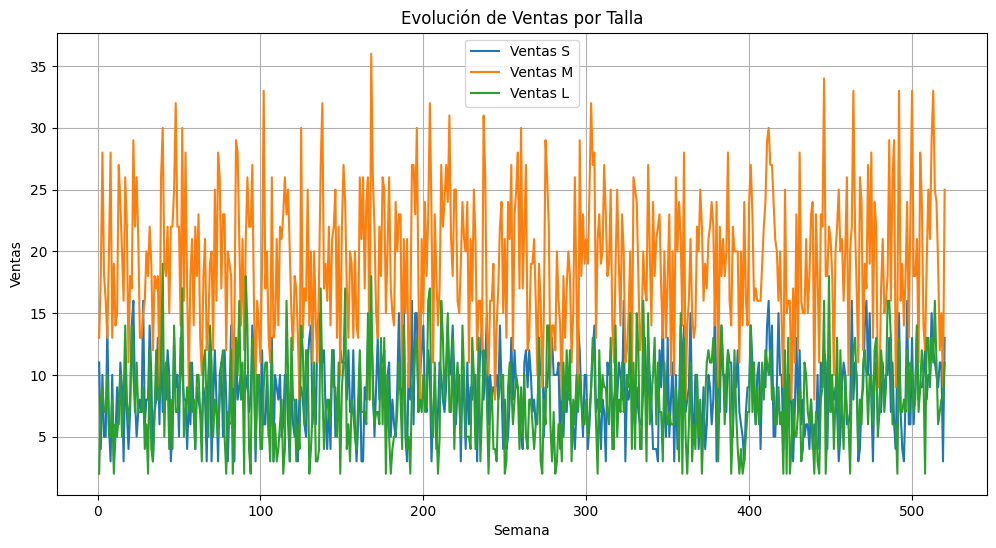

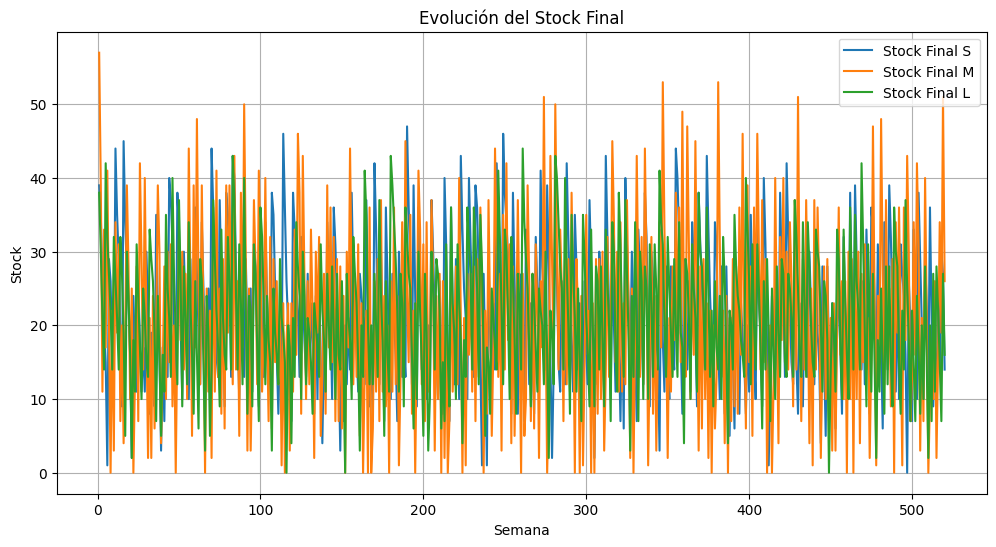

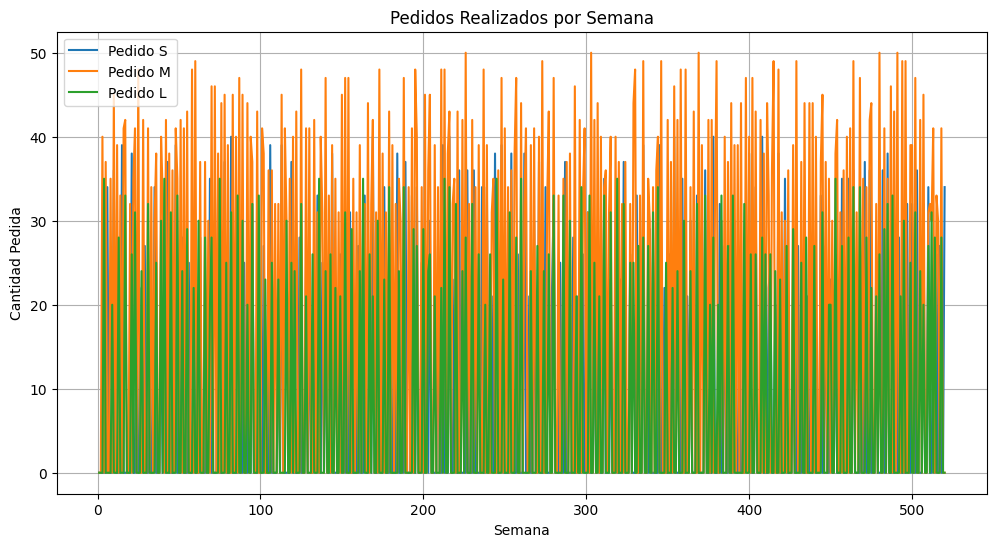

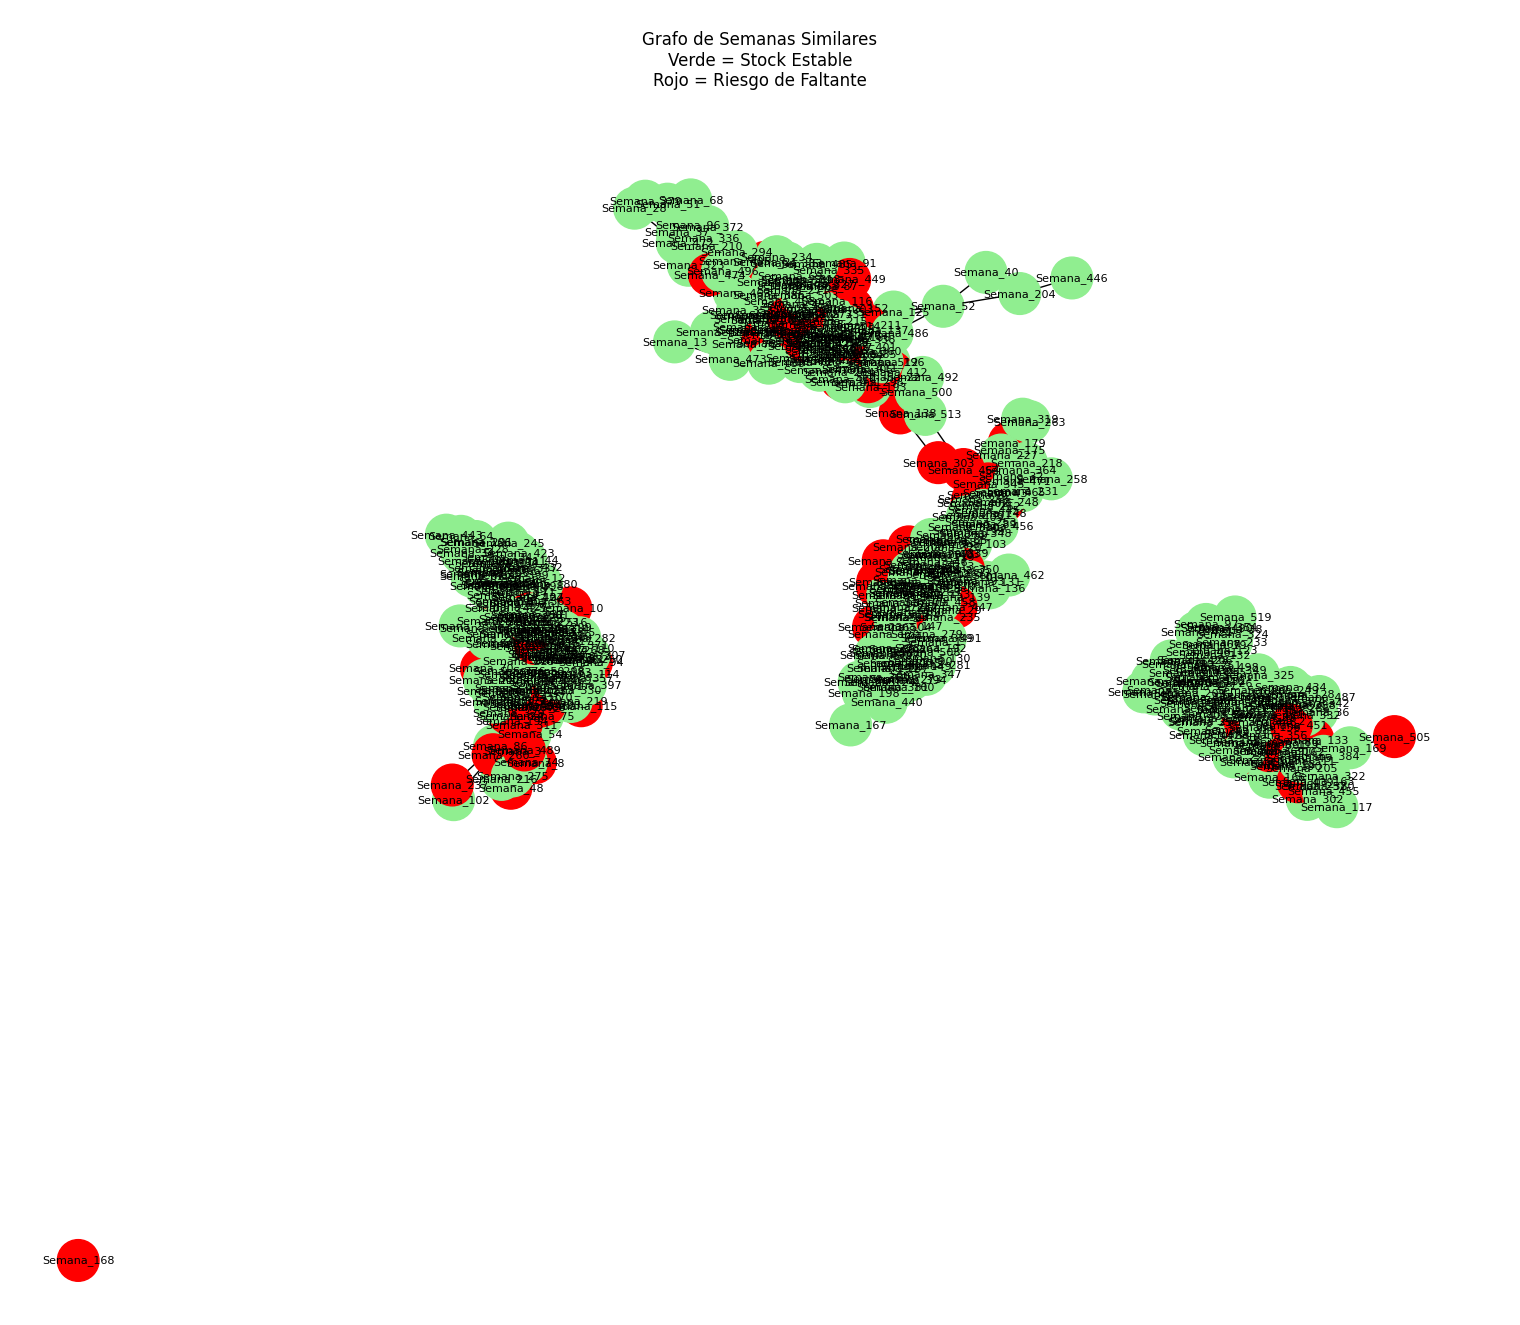

MÉTRICAS GENERALES
Total de semanas analizadas: 520

Semanas con riesgo de faltante:
101


Porcentaje de semanas críticas:
19.42%


Interpretación:
El sistema identificó semanas históricas
con posibles problemas de abastecimiento.

Los nodos rojos representan semanas
donde existió riesgo de faltante.



In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# CARGAR CSV
# ==========================================

df = pd.read_csv("inventario_semanal.csv")

# ==========================================
# GRÁFICO 1
# EVOLUCIÓN DE VENTAS
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(df["id_semana"], df["ventas_S"], label="Ventas S")
plt.plot(df["id_semana"], df["ventas_M"], label="Ventas M")
plt.plot(df["id_semana"], df["ventas_L"], label="Ventas L")

plt.title("Evolución de Ventas por Talla")
plt.xlabel("Semana")
plt.ylabel("Ventas")

plt.legend()
plt.grid(True)

plt.show()

# ==========================================
# GRÁFICO 2
# EVOLUCIÓN DEL STOCK FINAL
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(df["id_semana"], df["stock_final_S"], label="Stock Final S")
plt.plot(df["id_semana"], df["stock_final_M"], label="Stock Final M")
plt.plot(df["id_semana"], df["stock_final_L"], label="Stock Final L")

plt.title("Evolución del Stock Final")
plt.xlabel("Semana")
plt.ylabel("Stock")

plt.legend()
plt.grid(True)

plt.show()

# ==========================================
# GRÁFICO 3
# PEDIDOS REALIZADOS
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(df["id_semana"], df["pedido_realizado_S"], label="Pedido S")
plt.plot(df["id_semana"], df["pedido_realizado_M"], label="Pedido M")
plt.plot(df["id_semana"], df["pedido_realizado_L"], label="Pedido L")

plt.title("Pedidos Realizados por Semana")
plt.xlabel("Semana")
plt.ylabel("Cantidad Pedida")

plt.legend()
plt.grid(True)

plt.show()

# ==========================================
# CREAR GRAFO
# ==========================================

G = nx.Graph()

# ------------------------------------------
# AGREGAR NODOS
# ------------------------------------------

for _, fila in df.iterrows():

    nodo = f"Semana_{fila['id_semana']}"

    riesgo = (
        fila['faltante_S'] or
        fila['faltante_M'] or
        fila['faltante_L']
    )

    G.add_node(
        nodo,
        riesgo=riesgo
    )

# ------------------------------------------
# CREAR CONEXIONES
# ------------------------------------------

UMBRAL_DIFERENCIA = 5

for i in range(len(df)):

    for j in range(i + 1, len(df)):

        fila1 = df.iloc[i]
        fila2 = df.iloc[j]

        nodo1 = f"Semana_{fila1['id_semana']}"
        nodo2 = f"Semana_{fila2['id_semana']}"

        diferencia = (
            abs(fila1['ventas_S'] - fila2['ventas_S']) +
            abs(fila1['ventas_M'] - fila2['ventas_M']) +
            abs(fila1['ventas_L'] - fila2['ventas_L'])
        )

        misma_temporada = (
            fila1['temporada'] == fila2['temporada']
        )

        if diferencia <= UMBRAL_DIFERENCIA and misma_temporada:

            G.add_edge(nodo1, nodo2)

# ==========================================
# COLORES DEL GRAFO
# ==========================================

colores = []

for nodo in G.nodes():

    if G.nodes[nodo]['riesgo']:
        colores.append("red")

    else:
        colores.append("lightgreen")

# ==========================================
# VISUALIZAR GRAFO
# ==========================================

plt.figure(figsize=(15, 12))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,

    with_labels=True,

    node_color=colores,

    node_size=900,

    font_size=8
)

plt.title("""
Grafo de Semanas Similares
Verde = Stock Estable
Rojo = Riesgo de Faltante
""")

plt.show()

# ==========================================
# MÉTRICAS GENERALES
# ==========================================

total_semanas = len(df)

semanas_riesgo = df[
    (df["faltante_S"] == True) |
    (df["faltante_M"] == True) |
    (df["faltante_L"] == True)
]

cantidad_riesgo = len(semanas_riesgo)

porcentaje_riesgo = (
    cantidad_riesgo / total_semanas
) * 100

# ==========================================
# RESULTADOS
# ==========================================

print("===================================")
print("MÉTRICAS GENERALES")
print("===================================")

print(f"Total de semanas analizadas: {total_semanas}")

print(f"""
Semanas con riesgo de faltante:
{cantidad_riesgo}
""")

print(f"""
Porcentaje de semanas críticas:
{porcentaje_riesgo:.2f}%
""")

print("""
Interpretación:
El sistema identificó semanas históricas
con posibles problemas de abastecimiento.

Los nodos rojos representan semanas
donde existió riesgo de faltante.
""")